In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import fdfi
print(fdfi.__version__)
from fdfi.explainers import EOTExplainer


0.0.5


## Load Data And Feature Groups


In [2]:
DATA_DIR = Path("data")

DATASETS = {
    "sens50": {
        "file": DATA_DIR / "sens50_processed_dataset.csv",
        "target": "sens50",
    },
    "sens80": {
        "file": DATA_DIR / "sens80_processed_dataset.csv",
        "target": "sens80",
    },
    "ic50": {
        "file": DATA_DIR / "ic50.censored_processed_dataset.csv",
        "target": "ic50.censored",
    },
}

outcome = "sens50"

cfg = DATASETS[outcome]
filename = str(cfg["file"])

data = pd.read_csv(cfg["file"])
y = data[cfg["target"]].astype(int)
X = data.drop(columns=[cfg["target"]])

df_groups = pd.read_csv(DATA_DIR / "feature_group.csv", index_col=0).set_index("feature")
df_groups = pd.get_dummies(df_groups["group"]).groupby(df_groups.index).max().reindex(X.columns)

print(f"Dataset shape: {X.shape}")
print(f"Target variable: {outcome}")
print(f"Number of groups: {len(df_groups.columns)}")
print(f"Data loaded from: {filename}")


Dataset shape: (611, 832)
Target variable: sens50
Number of groups: 14
Data loaded from: data/sens50_processed_dataset.csv


In [3]:
print("Data preparation...")

preprocess = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    StandardScaler(),
)

X_values = preprocess.fit_transform(X)
y_values = y.values.astype(float)

# Standardize y to N(0,1) to match DFI paper (scale-invariant for z-scores
# but ensures the DFI UEIF formula (y - ỹ)² - (y - ŷ)² works in the same
# unit system as the reference implementation)
y_scaler = StandardScaler()
y_values = y_scaler.fit_transform(y_values.reshape(-1, 1)).ravel()

print("Data preparation finished")
print(f"Feature matrix shape: {X_values.shape}")
print(f"y statistics: mean={y_values.mean():.3f}, std={y_values.std():.3f}")
print(f"Missing values - X: {np.isnan(X_values).sum()}, y: {np.isnan(y_values).sum()}")


Data preparation...
Data preparation finished
Feature matrix shape: (611, 832)
y statistics: mean=-0.000, std=1.000
Missing values - X: 0, y: 0


In [4]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    random_state=0,
    n_jobs=-1,
)
rf.fit(X_values, y_values)
model_fn = lambda X_: rf.predict(X_)
print(f"RandomForestRegressor fitted on full data")
print(f"Train R²: {rf.score(X_values, y_values):.3f}")


RandomForestRegressor fitted on full data
Train R²: 0.705


## Fit EOT FDFI


In [5]:
nsamples_main = 50

start_time = time.time()

fdfi_estimator = EOTExplainer(
    model=model_fn,
    data=X_values,
    nsamples=nsamples_main,
    epsilon=0.001,
    sampling_method="resample",
    random_state=0,
)

eot_results = fdfi_estimator(X_values, y=y_values)

dfi_time = time.time() - start_time

print(f"EOT FDFI completed in {dfi_time:.2f} seconds")
print(f"DFI scores shape: {eot_results['phi_X'].shape}")

np.sum(eot_results["phi_X"]), np.sum(eot_results["phi_Z"])


EOT FDFI completed in 434.01 seconds
DFI scores shape: (832,)


(0.7396973904611802, 0.7396975752008004)

## Individual Feature Inference With conf_int()

In [6]:
ci_X = fdfi_estimator.conf_int(
    alpha=0.05,
    target="X",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
    verbose=False,
)

ci_Z = fdfi_estimator.conf_int(
    alpha=0.05,
    target="Z",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
    verbose=False,
)


## Feature-Level Summary

In [7]:
print("=== X-space feature summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="X",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
)

print("\n=== Z-space feature summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="Z",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
)

=== X-space feature summary ===
Feature Importance Results
Method: EOTExplainer
Number of units: 832
Significance level: 0.05
Alternative: two-sided
Margin method: mixture
Practical margin: 0.0028
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig
------------------------------------------------------------------------------
              0     0.0011     0.0018    -0.0026     0.0047     0.3314      
              1     0.0013     0.0019    -0.0023     0.0050     0.4123      
              2     0.0016     0.0018    -0.0020     0.0052     0.5027      
              3     0.0003     0.0018    -0.0032     0.0039     0.1639      
              4     0.0005     0.0018    -0.0031     0.0040     0.1935      
              5     0.0007     0.0018    -0.0029     0.0042     0.2342      
              6     0.0004     0.0018    -0.0031     0.0040     0.1831      
              7     0.0004   

## Group Importance

In [8]:
res_df = fdfi_estimator.conf_int(
    alpha=0.05,
    target="X",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
    verbose=False,
)
res_df = pd.DataFrame({
    "group":       res_df["groups"],
    "importance":  res_df["score"],
    "se":          res_df["se"],
    "zscore":      res_df["zscore"],
    "ci_lower":    res_df["ci_lower"],
    "ci_upper":    res_df["ci_upper"],
    "p_value":     res_df["pvalue"],
    "p_value_adj": res_df.get("pvalue_adj", res_df["pvalue"]),
    "reject_null": res_df["reject_null"],
})


## Group Summary Table

In [9]:
print("=== X-space group summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="X",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
)
print("\n=== Z-space group summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="Z",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
)


=== X-space group summary ===
Feature Importance Results
Method: EOTExplainer
Number of units: 14
Significance level: 0.05
Alternative: two-sided
Multiple testing: bonferroni
Margin method: fixed
------------------------------------------------------------------------------
          Group   Estimate    Std Err   CI Lower   CI Upper  Adj P-val   Sig
------------------------------------------------------------------------------
          cd4bs     0.1073     0.0097     0.0883     0.1262     0.0000   ***
          covar     0.2089     0.0161     0.1774     0.2403     0.0000   ***
      cysteines     0.0119     0.0042     0.0037     0.0201     0.0616     *
            esa     0.0983     0.0088     0.0810     0.1156     0.0000   ***
           geog     0.0031     0.0041    -0.0048     0.0111     1.0000      
       geometry     0.0359     0.0050     0.0262     0.0456     0.0000   ***
          glyco     0.0541     0.0058     0.0428     0.0654     0.0000   ***
           gp41     0.0270    

## Group Mapping

In [10]:
group_mapping = pd.DataFrame({
    "group_num": range(1, 15),
    "group": [
        "vrc01", "cd4bs", "esa", "glyco", "covar", "pngs", "gp41",
        "pngs_novrc01", "subtype", "sequons", "geometry", "cysteines",
        "steric_bulk", "geog"
    ],
    "description": [
        "VRC01 binding footprint",
        "CD4 binding sites",
        "Sites with sufficient exposed surface area",
        "Sites identified as important for glycosylation",
        "Sites with residues that covary with\nthe VRC01 binding footprint",
        "Sites associated with VRC01-specific\npotential N-linked glycosylation (PNGS) effects",
        "gp41 sites important for VRC01 binding",
        "Sites for indicating N-linked glycosylation",
        "Majority virus subtypes",
        "Region-specific counts of PNGS",
        "Viral geometry",
        "Cysteine counts",
        "Steric bulk at critical locations",
        "Geographic confounders",
    ],
})


## Group Importance Plot

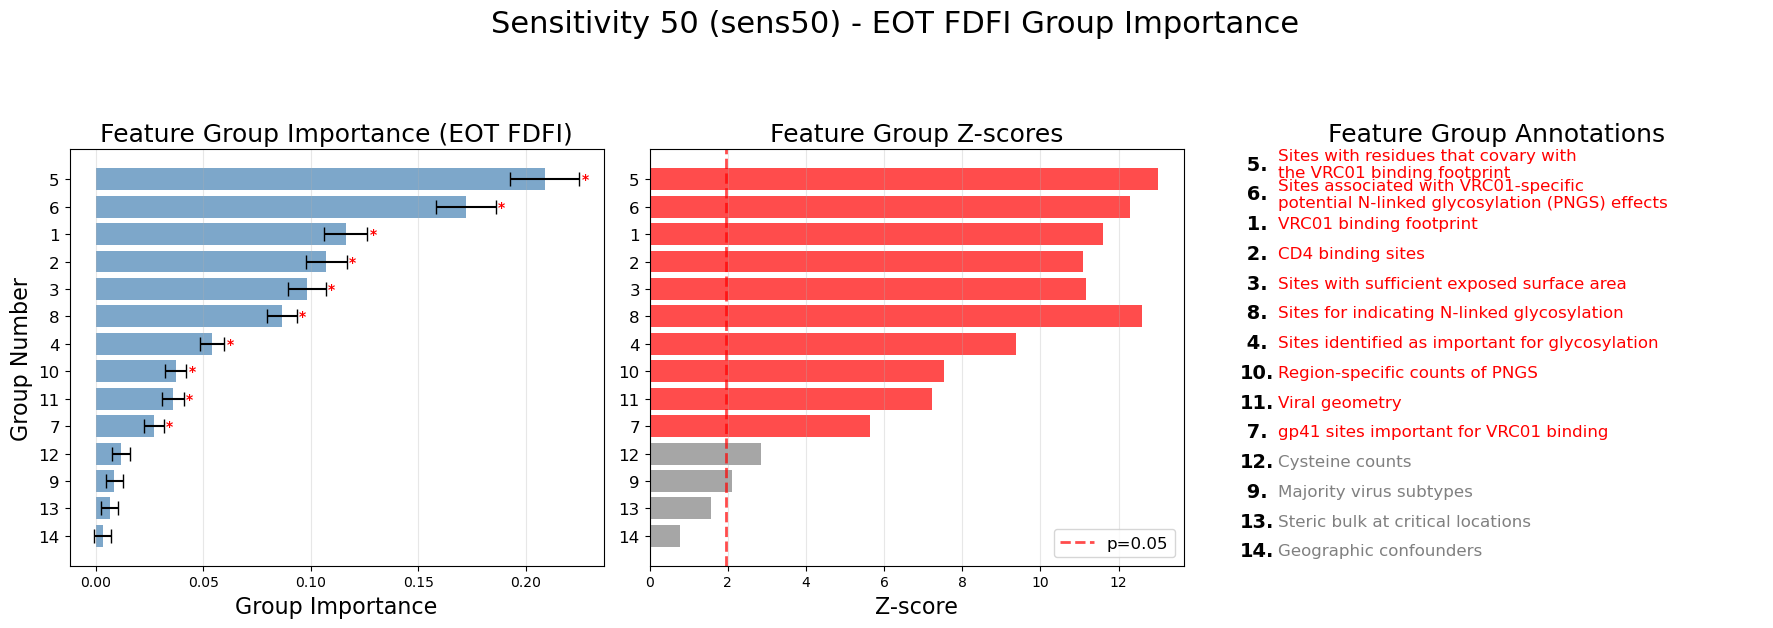

In [11]:
DATASET_LABELS = {
    "sens50": "Sensitivity 50",
    "sens80": "Sensitivity 80",
    "ic50": "IC50 Censored",
}
dataset_label = DATASET_LABELS.get(outcome, outcome)

group_df_sorted = res_df.sort_values("importance", ascending=True).reset_index(drop=True)
group_df_sorted = group_df_sorted.merge(group_mapping, on="group", how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"width_ratios": [3, 3, 3]})
fig.suptitle(
    f"{dataset_label} ({outcome}) - EOT FDFI Group Importance",
    fontsize=22,
    y=1.04,
)

group_numbers = list(group_df_sorted["group_num"])

ax1 = axes[0]
ax1.barh(
    range(len(group_df_sorted)),
    group_df_sorted["importance"],
    xerr=group_df_sorted["se"],
    error_kw=dict(capsize=5),
    alpha=0.7,
    color="steelblue",
)
ax1.set_yticks(range(len(group_df_sorted)))
ax1.set_yticklabels(group_numbers, fontsize=12)
ax1.set_xlabel("Group Importance", fontsize=16)
ax1.set_title("Feature Group Importance (EOT FDFI)", fontsize=18)
ax1.set_ylabel("Group Number", fontsize=16)
ax1.grid(axis="x", alpha=0.3)

for i, (_, row) in enumerate(group_df_sorted.iterrows()):
    if row["reject_null"]:
        ax1.text(
            row["importance"] + row["se"] + 0.001,
            i,
            "*",
            va="center",
            fontweight="bold",
            color="red",
        )

ax2 = axes[1]
colors = ["red" if reject_null else "gray" for reject_null in group_df_sorted["reject_null"]]
ax2.barh(range(len(group_df_sorted)), group_df_sorted["zscore"], alpha=0.7, color=colors)
ax2.set_yticks(range(len(group_df_sorted)))
ax2.set_yticklabels(group_numbers, fontsize=12)
ax2.set_xlabel("Z-score", fontsize=16)
ax2.set_title("Feature Group Z-scores", fontsize=18)
ax2.grid(axis="x", alpha=0.3)
ax2.axvline(x=1.96, color="red", linestyle="--", linewidth=2, alpha=0.7, label="p=0.05")
ax2.legend(fontsize=12)

ax3 = axes[2]
ax3.set_xlim(0, 1)
ax3.set_ylim(-0.5, len(group_df_sorted) - 0.5)

for i, (_, row) in enumerate(group_df_sorted.iterrows()):
    group_name = row["group"]
    display_name = row["description"] if pd.notna(row["description"]) else group_name
    text_color = "red" if row["reject_null"] else "gray"

    ax3.text(
        0.02,
        i,
        f"{int(row['group_num']):2d}.",
        va="center",
        ha="left",
        fontsize=14,
        fontweight="bold",
        color="black",
    )
    ax3.text(
        0.09,
        i,
        display_name,
        va="center",
        ha="left",
        fontsize=12,
        color=text_color,
    )

ax3.set_yticks([])
ax3.set_xticks([])
ax3.set_title("Feature Group Annotations", fontsize=18)
for spine in ax3.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Summary

This notebook applies **EOT FDFI** (Entropic Optimal Transport Disentangled Feature Importance)
with 5-fold cross-fitting to the `sens50` HIV neutralization dataset (d=832 binary features, n≈300).

**Why EOT over FlowMatching?**  
FlowExplainer X-space attribution relies on the flow Jacobian H = dX/dZ.
For binary high-d data (d >> n), H≈I (near-identity), making X-space DFI unreliable.
EOTExplainer uses an analytical whitening map and coupling moments — no Jacobian issues.

**Results (α = 0.05, Bonferroni correction over 14 groups):**  
See the group summary table and plot above for significant feature groups.


In [12]:
print("=== Group-level results (matching DFI paper) ===")
print(f"{'Group':<20} {'Importance':>12} {'SE':>10} {'Z-score':>10} {'Significant':>12}")
print("-" * 70)
for _, row in res_df.sort_values("zscore", ascending=False).iterrows():
    sig = "***" if row["reject_null"] else ""
    print(f"{row['group']:<20} {row['importance']:>12.4f} {row['se']:>10.4f} {row['zscore']:>10.2f} {sig:>12}")

n_sig = res_df["reject_null"].sum()
print(f"\nSignificant groups: {n_sig}/{len(res_df)} (Bonferroni alpha=0.05)")
print(f"Z-score range: {res_df['zscore'].min():.2f} to {res_df['zscore'].max():.2f}")


=== Group-level results (matching DFI paper) ===
Group                  Importance         SE    Z-score  Significant
----------------------------------------------------------------------
covar                      0.2089     0.0161      13.01          ***
pngs_novrc01               0.0867     0.0069      12.61          ***
pngs                       0.1721     0.0140      12.29          ***
vrc01                      0.1163     0.0100      11.59          ***
esa                        0.0983     0.0088      11.15          ***
cd4bs                      0.1073     0.0097      11.09          ***
glyco                      0.0541     0.0058       9.37          ***
sequons                    0.0372     0.0049       7.54          ***
geometry                   0.0359     0.0050       7.23          ***
gp41                       0.0270     0.0048       5.64          ***
cysteines                  0.0119     0.0042       2.85             
subtype                    0.0087     0.0041       2